In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [4]:
file_path = "../data/processed/feature_engineered_ev_dataset.csv"

master_df = pd.read_csv(file_path)

In [2]:
features = [
    "ev_stock_lag1",
    "ev_stock_share_lag1",
    "charging_points_lag1"
]

target = "ev_sales_share"

In [5]:
model_df = master_df[
    ["country", "year"] + features + [target]
].dropna().copy()

print("Modelling dataset shape:", model_df.shape)

print("\nMissing values:")
print(model_df.isnull().sum())

print("\nYears available:")
print(sorted(model_df["year"].unique()))

Modelling dataset shape: (499, 6)

Missing values:
country                 0
year                    0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
ev_sales_share          0
dtype: int64

Years available:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [6]:
train_df = model_df[
    model_df["year"] <= 2022
].copy()

test_df = model_df[
    model_df["year"].isin([2023, 2024])
].copy()


X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]


print("\nTraining data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

print("\nTraining years:")
print(sorted(train_df["year"].unique()))

print("\nTesting years:")
print(sorted(test_df["year"].unique()))


Training data shape: (421, 3)
Testing data shape : (78, 3)

Training years:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Testing years:
[np.int64(2023), np.int64(2024)]


In [7]:
rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)

rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

print("\nRandom Forest Results")

print(f"R²   : {rf_r2:.4f}")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")


Random Forest Results
R²   : 0.7336
MAE  : 7.4794
RMSE : 10.6366


In [8]:
rf_results = test_df[
    ["country", "year"]
].copy()

rf_results["actual_ev_sales_share"] = y_test.values

rf_results["predicted_ev_sales_share"] = y_pred_rf

rf_results["error"] = (
    rf_results["actual_ev_sales_share"]
    - rf_results["predicted_ev_sales_share"]
)

rf_results["absolute_error"] = (
    rf_results["error"].abs()
)


print("\nRandom Forest Prediction Results:")

print(
    rf_results
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
)


Random Forest Prediction Results:
         country  year  actual_ev_sales_share  predicted_ev_sales_share  \
190      Iceland  2024                   42.0                    74.970   
167      Germany  2024                   19.0                    45.410   
440  Switzerland  2024                   28.0                    54.000   
37       Belgium  2024                   43.0                    68.420   
307  Netherlands  2024                   48.0                    70.100   
91         China  2024                   48.0                    68.180   
427       Sweden  2024                   58.0                    77.920   
321  New Zealand  2024                   11.0                    30.820   
226       Israel  2024                   21.0                    39.270   
268        Korea  2024                    9.2                    26.996   

      error  absolute_error  
190 -32.970          32.970  
167 -26.410          26.410  
440 -26.000          26.000  
37  -25.420        

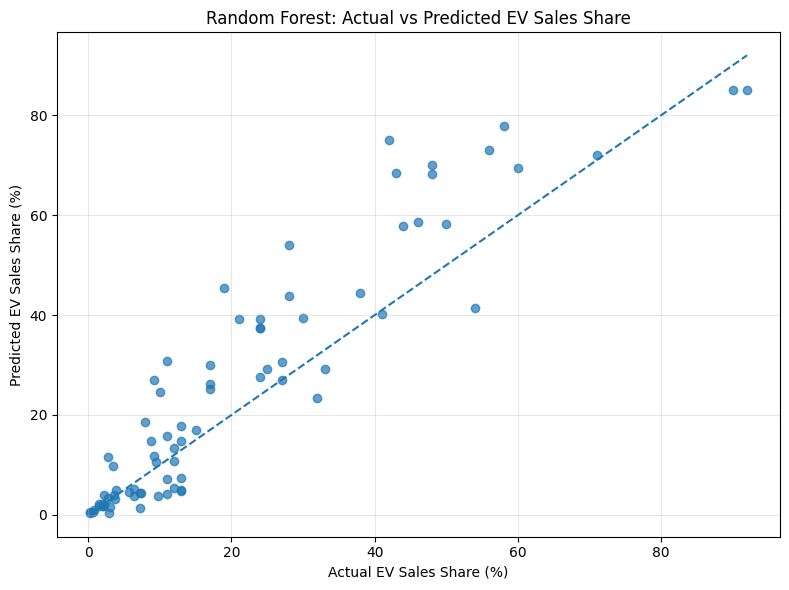

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    y_pred_rf.min()
)

max_value = max(
    y_test.max(),
    y_pred_rf.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual EV Sales Share (%)")

plt.ylabel("Predicted EV Sales Share (%)")

plt.title(
    "Random Forest: Actual vs Predicted EV Sales Share"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [10]:
rf_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


print("\nRandom Forest Feature Importance:")

print(rf_feature_importance)


Random Forest Feature Importance:
                Feature  Importance
1   ev_stock_share_lag1    0.964899
2  charging_points_lag1    0.018581
0         ev_stock_lag1    0.016520


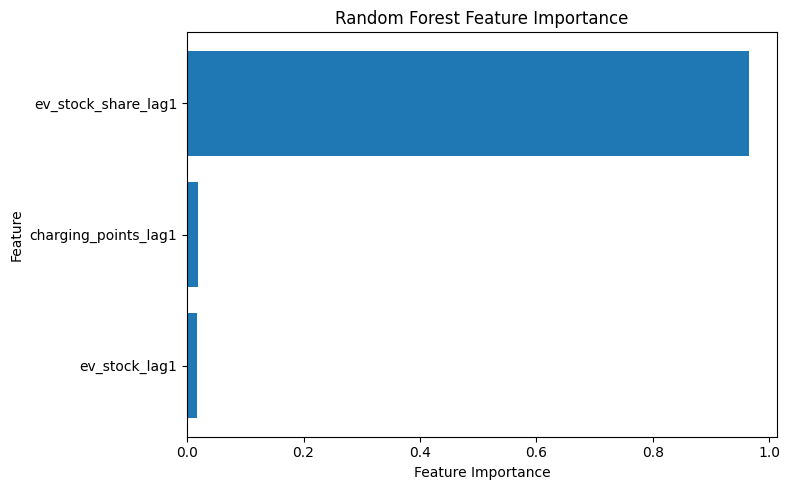

In [11]:
plt.figure(figsize=(8, 5))

plt.barh(
    rf_feature_importance["Feature"],
    rf_feature_importance["Importance"]
)

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.title(
    "Random Forest Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


In [12]:
print("\nActual EV Sales Share Range:")

print(
    y_test.min(),
    "to",
    y_test.max()
)


print("\nRandom Forest Prediction Range:")

print(
    y_pred_rf.min(),
    "to",
    y_pred_rf.max()
)


Actual EV Sales Share Range:
0.22 to 92.0

Random Forest Prediction Range:
0.35044000000000003 to 84.99


In [13]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    
    "R2": [
        0.3693,
        rf_r2
    ],
    
    "MAE": [
        7.6718,
        rf_mae
    ],
    
    "RMSE": [
        16.3651,
        rf_rmse
    ]
})


print("\nModel Performance Comparison:")

print(model_comparison)


Model Performance Comparison:
               Model        R2       MAE       RMSE
0  Linear Regression  0.369300  7.671800  16.365100
1      Random Forest  0.733563  7.479407  10.636625


In [14]:
# ============================================================
# 15. RANDOM FOREST PERFORMANCE BY TEST YEAR
# ============================================================

yearly_rf_results = []

for year in sorted(rf_results["year"].unique()):

    year_results = rf_results[
        rf_results["year"] == year
    ]

    year_actual = year_results["actual_ev_sales_share"]

    year_predicted = year_results["predicted_ev_sales_share"]

    year_r2 = r2_score(
        year_actual,
        year_predicted
    )

    year_mae = mean_absolute_error(
        year_actual,
        year_predicted
    )

    year_rmse = np.sqrt(
        mean_squared_error(
            year_actual,
            year_predicted
        )
    )

    yearly_rf_results.append({
        "Year": year,
        "R2": year_r2,
        "MAE": year_mae,
        "RMSE": year_rmse
    })


yearly_rf_performance = pd.DataFrame(
    yearly_rf_results
)


print("\nRandom Forest Performance by Test Year:")

print(yearly_rf_performance)


Random Forest Performance by Test Year:
   Year        R2        MAE       RMSE
0  2023  0.906626   4.844738   6.459945
1  2024  0.541276  10.114077  13.584723


In [15]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# TEMPORAL CROSS-VALIDATION BY YEAR
# ============================================================


# ============================================================
# 16. IMPORT TUNING LIBRARIES
# ============================================================

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


# ============================================================
# 17. SORT TRAINING DATA BY YEAR
# ============================================================

train_df_tuning = (
    train_df
    .sort_values(["year", "country"])
    .reset_index(drop=True)
)


X_train_tuning = train_df_tuning[features]

y_train_tuning = train_df_tuning[target]


print("Training data used for tuning:")
print(X_train_tuning.shape)

print("\nTraining years:")
print(
    sorted(
        train_df_tuning["year"].unique()
    )
)


# ============================================================
# 18. CREATE TEMPORAL CROSS-VALIDATION FOLDS BY YEAR
# ============================================================

training_years = np.array(
    sorted(
        train_df_tuning["year"].unique()
    )
)


time_split = TimeSeriesSplit(
    n_splits=5
)


temporal_cv_splits = []


for train_year_index, validation_year_index in time_split.split(
    training_years
):

    cv_train_years = training_years[
        train_year_index
    ]

    cv_validation_years = training_years[
        validation_year_index
    ]


    cv_train_indices = train_df_tuning.index[
        train_df_tuning["year"].isin(
            cv_train_years
        )
    ].to_numpy()


    cv_validation_indices = train_df_tuning.index[
        train_df_tuning["year"].isin(
            cv_validation_years
        )
    ].to_numpy()


    temporal_cv_splits.append(
        (
            cv_train_indices,
            cv_validation_indices
        )
    )


# ============================================================
# 19. DISPLAY TEMPORAL VALIDATION FOLDS
# ============================================================

print("\nTemporal Cross-Validation Folds:")


for fold_number, (
    train_indices,
    validation_indices
) in enumerate(
    temporal_cv_splits,
    start=1
):

    fold_train_years = sorted(
        train_df_tuning
        .iloc[train_indices]["year"]
        .unique()
    )


    fold_validation_years = sorted(
        train_df_tuning
        .iloc[validation_indices]["year"]
        .unique()
    )


    print(
        f"\nFold {fold_number}"
    )

    print(
        "Training years  :",
        fold_train_years
    )

    print(
        "Validation years:",
        fold_validation_years
    )


# ============================================================
# 20. DEFINE RANDOM FOREST PARAMETER GRID
# ============================================================

rf_param_grid = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        5,
        10,
        15
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        1.0,
        "sqrt"
    ]
}


# ============================================================
# 21. CREATE RANDOM FOREST MODEL FOR TUNING
# ============================================================

rf_tuning_model = RandomForestRegressor(
    random_state=42
)


# ============================================================
# 22. CREATE GRID SEARCH
# ============================================================

rf_grid_search = GridSearchCV(

    estimator=rf_tuning_model,

    param_grid=rf_param_grid,

    scoring="neg_root_mean_squared_error",

    cv=temporal_cv_splits,

    n_jobs=-1,

    verbose=1
)


# ============================================================
# 23. RUN HYPERPARAMETER TUNING
# ============================================================

rf_grid_search.fit(
    X_train_tuning,
    y_train_tuning
)


# ============================================================
# 24. DISPLAY BEST PARAMETERS
# ============================================================

print(
    "\nBest Random Forest Parameters:"
)

print(
    rf_grid_search.best_params_
)


print(
    "\nBest Temporal Validation RMSE:"
)

print(
    -rf_grid_search.best_score_
)


# ============================================================
# 25. RETRIEVE BEST RANDOM FOREST MODEL
# ============================================================

best_rf_model = (
    rf_grid_search.best_estimator_
)


# ============================================================
# 26. GENERATE FINAL TEST PREDICTIONS
# ============================================================

y_pred_rf_tuned = best_rf_model.predict(
    X_test
)


# ============================================================
# 27. EVALUATE TUNED RANDOM FOREST
# ============================================================

rf_tuned_r2 = r2_score(
    y_test,
    y_pred_rf_tuned
)


rf_tuned_mae = mean_absolute_error(
    y_test,
    y_pred_rf_tuned
)


rf_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf_tuned
    )
)


print(
    "\nTuned Random Forest Results"
)

print(
    f"R²   : {rf_tuned_r2:.4f}"
)

print(
    f"MAE  : {rf_tuned_mae:.4f}"
)

print(
    f"RMSE : {rf_tuned_rmse:.4f}"
)


# ============================================================
# 28. COMPARE DEFAULT AND TUNED RANDOM FOREST
# ============================================================

rf_model_comparison = pd.DataFrame({

    "Model": [
        "Default Random Forest",
        "Tuned Random Forest"
    ],

    "R2": [
        rf_r2,
        rf_tuned_r2
    ],

    "MAE": [
        rf_mae,
        rf_tuned_mae
    ],

    "RMSE": [
        rf_rmse,
        rf_tuned_rmse
    ]
})


print(
    "\nRandom Forest Model Comparison:"
)

print(
    rf_model_comparison
)


# ============================================================
# 29. CREATE TUNED RANDOM FOREST RESULTS DATAFRAME
# ============================================================

rf_tuned_results = test_df[
    ["country", "year"]
].copy()


rf_tuned_results[
    "actual_ev_sales_share"
] = y_test.values


rf_tuned_results[
    "predicted_ev_sales_share"
] = y_pred_rf_tuned


rf_tuned_results["error"] = (

    rf_tuned_results[
        "actual_ev_sales_share"
    ]

    -

    rf_tuned_results[
        "predicted_ev_sales_share"
    ]

)


rf_tuned_results["absolute_error"] = (

    rf_tuned_results[
        "error"
    ].abs()

)


print(
    "\nLargest Tuned Random Forest Prediction Errors:"
)


print(

    rf_tuned_results

    .sort_values(
        "absolute_error",
        ascending=False
    )

    .head(10)

)


# ============================================================
# 30. TUNED RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_tuned_feature_importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        best_rf_model.feature_importances_

})


rf_tuned_feature_importance = (

    rf_tuned_feature_importance

    .sort_values(
        "Importance",
        ascending=False
    )

)


print(
    "\nTuned Random Forest Feature Importance:"
)


print(
    rf_tuned_feature_importance
)


# ============================================================
# 31. CHECK TUNED PREDICTION RANGE
# ============================================================

print(
    "\nActual EV Sales Share Range:"
)

print(
    y_test.min(),
    "to",
    y_test.max()
)


print(
    "\nTuned Random Forest Prediction Range:"
)

print(
    y_pred_rf_tuned.min(),
    "to",
    y_pred_rf_tuned.max()
)

Training data used for tuning:
(421, 3)

Training years:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Temporal Cross-Validation Folds:

Fold 1
Training years  : [np.int64(2011), np.int64(2012)]
Validation years: [np.int64(2013), np.int64(2014)]

Fold 2
Training years  : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
Validation years: [np.int64(2015), np.int64(2016)]

Fold 3
Training years  : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Validation years: [np.int64(2017), np.int64(2018)]

Fold 4
Training years  : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Validation years: [np.int64(2019), np.int64(2020)]

Fold 5
Training years  : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(